In [1]:
from ultralytics import YOLO
import onnxruntime as ort
import os
import shutil
import matplotlib.pyplot as plt
import cv2
import random
import time
import torch
import numpy as np

In [3]:
# 디렉토리 생성
for split in ['train', 'valid', 'test']:
    os.makedirs(f'dataset/fruit_Dataset/{split}/images', exist_ok=True)
    os.makedirs(f'dataset/fruit_Dataset//{split}/labels', exist_ok=True)

In [4]:
class_dict = {0: 'apple', 1: 'banana', 2: 'orange'}
print(list(class_dict.values()))
print(len(class_dict))

yaml_path = os.path.join('dataset/fruit_Dataset', 'data.yaml')
with open(yaml_path, 'w', encoding='utf-8') as f:
    f.write('train: ../train/images\n')
    f.write('val: ../valid/images\n')
    f.write('test: ../test/images\n')
    f.write('\n')
    f.write(f"nc: {len(class_dict)}\n")
    f.write(f"names: {list(class_dict.values())}")

['apple', 'banana', 'orange']
3


In [6]:
fruit_dataset_dir = 'dataset/fruit_Dataset'

dest_dir = 'dataset/fruit_Dataset'

src_image_path = os.path.join(fruit_dataset_dir, 'images')
src_label_path = os.path.join(fruit_dataset_dir, 'labels')

src_image_list = [f for f in os.listdir(src_image_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
src_label_list = [f for f in os.listdir(src_label_path) if f.endswith('.txt')]

print(len(src_image_list))
print(len(src_label_list))

random.seed(42)
random.shuffle(src_image_list)

split_idx = int(len(src_image_list) * 0.8)
train_image_list = src_image_list[:split_idx]
val_image_list = src_image_list[split_idx:]

print(len(train_image_list))
print(len(val_image_list))

list_dict = {'train': train_image_list, 'valid': val_image_list}

for split, image_list in list_dict.items():
    image_copy_count = 0
    label_copy_count = 0
    
    for image in image_list: # 이미지는 항상 존재하지만, 라벨은 없을수도 있다.
        label = image.replace('.png', '.txt')
        image_path = os.path.join(src_image_path, image)
        label_path = os.path.join(src_label_path, label)

        dest_image_path = os.path.join(dest_dir, split, 'images', image)
        dest_label_path = os.path.join(dest_dir, split, 'labels', label)

        if os.path.exists(image_path):
            shutil.copy(image_path, dest_image_path)
            image_copy_count += 1
        
        if os.path.exists(label_path):
            shutil.copy(label_path, dest_label_path)
            label_copy_count += 1
        else:
            print(f'label_path: {label_path}')
        # break

    print(f'image_copy_count: {image_copy_count} | label_copy_count: {label_copy_count}')

1500
1498
1200
300
label_path: dataset/fruit_Dataset/labels/fruit_0185.txt
label_path: dataset/fruit_Dataset/labels/fruit_0899.txt
image_copy_count: 1200 | label_copy_count: 1198
image_copy_count: 300 | label_copy_count: 300


image_path: dataset/fruit_Dataset/images/fruit_0808.png


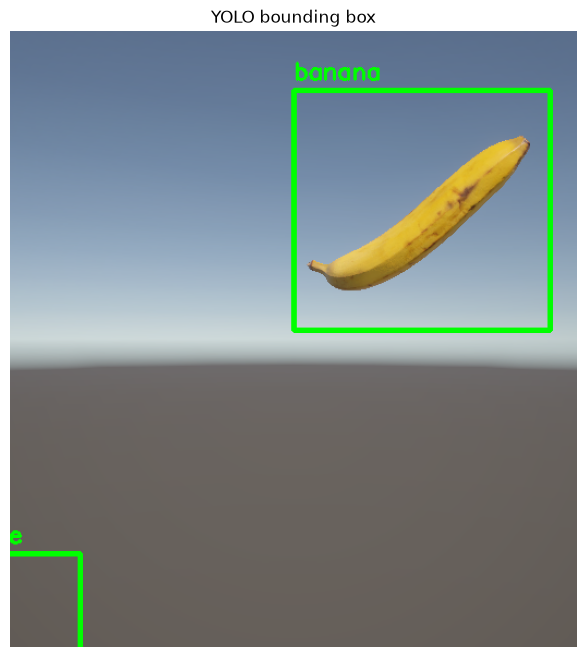

image_path: dataset/fruit_Dataset/images/fruit_1371.png


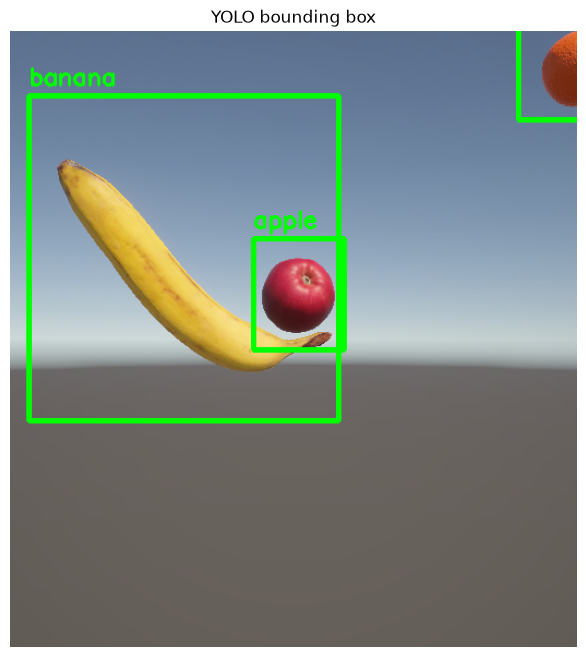

image_path: dataset/fruit_Dataset/images/fruit_0226.png


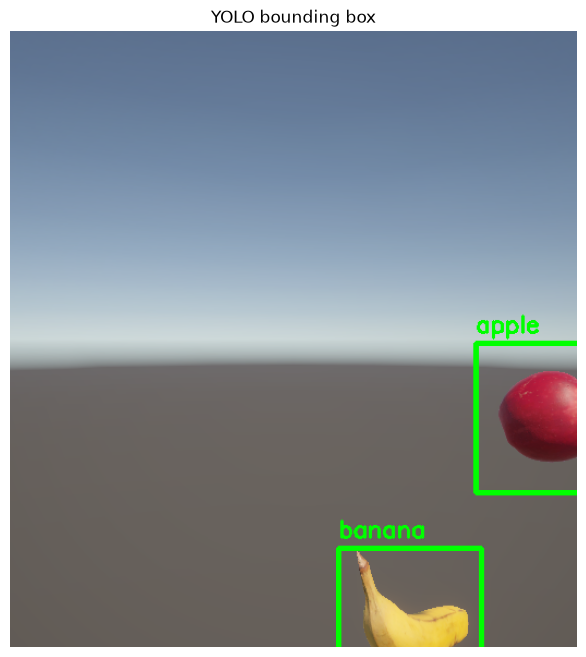

image_path: dataset/fruit_Dataset/images/fruit_1009.png


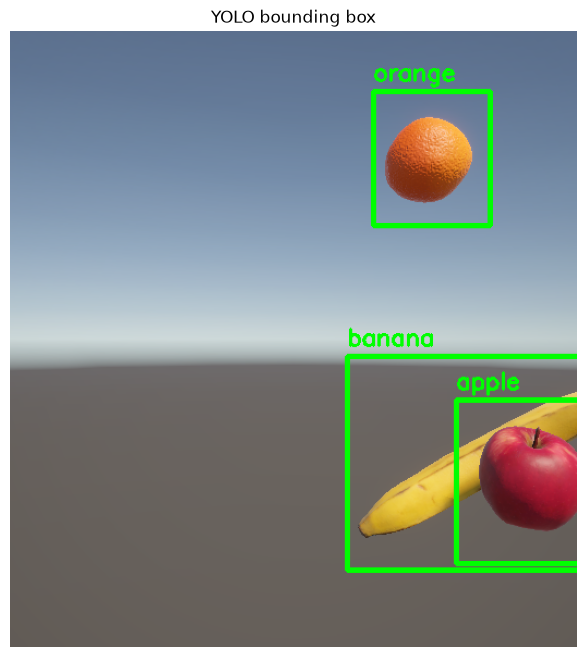

image_path: dataset/fruit_Dataset/images/fruit_0771.png


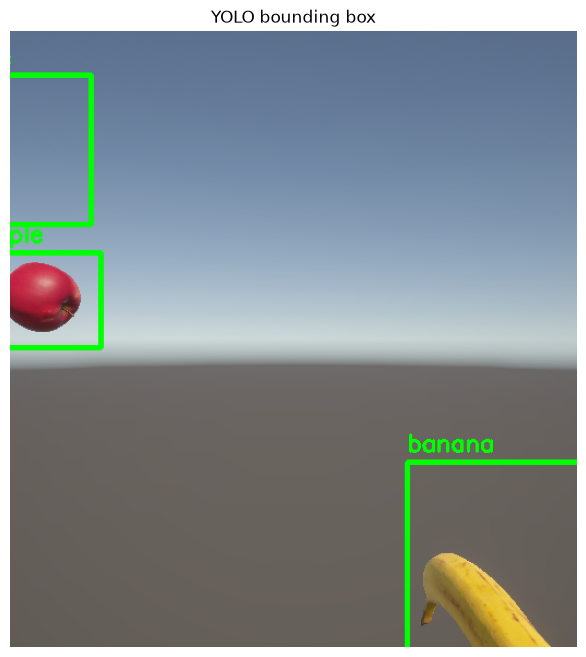

In [10]:
picked_labels = random.sample(src_label_list, k=5)

for label in picked_labels:
    image = label.replace('.txt', '.png')
    image_path = os.path.join(fruit_dataset_dir, 'images', image)
    label_path = os.path.join(fruit_dataset_dir, 'labels', label)

    if not os.path.exists(image_path) or not os.path.exists(label_path):
        print('지정한 경로에 이미지나 파일이 없습니다.')
    else:
        print(f'image_path: {image_path}')
        img = cv2.imread(image_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img_rgb.shape

        with open(label_path, 'r') as f:
            lines = f.readlines()
        
        for line in lines:
            cls_id, cx, cy, bw, bh = map(float, line.split())
            cls_name = class_dict[cls_id]

            cx_pixel = cx * w
            cy_pixel = cy * h
            bw_pixel = bw * w
            bh_pixel = bh * h

            xmin = int( cx_pixel - (bw_pixel / 2) )
            ymin = int( cy_pixel - (bh_pixel / 2) )
            xmax = int( cx_pixel + (bw_pixel / 2) )
            ymax = int( cy_pixel + (bh_pixel / 2) )

            cv2.rectangle(img_rgb, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)
            cv2.putText(img_rgb, cls_name, (xmin, ymin-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        
        plt.figure(figsize=(10, 8))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title('YOLO bounding box')
        plt.show()

In [12]:
model = YOLO('yolov8n.pt')

current_dir = os.getcwd()

model.train(
    data=yaml_path, 
    epochs=20, 
    imgsz=640, 
    device='mps', 
    project=os.path.join(current_dir, 'runs'), 
    name='3fruits'
)

New https://pypi.org/project/ultralytics/8.4.139 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/fruit_Dataset/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=3fruits, nbs=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x16bc3e110>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [13]:
pt_weight_path = 'runs/3fruits/weights/best.pt'
save_dir = 'runs/3fruits/weights'

model = YOLO(pt_weight_path)

model.export(format='onnx', half=False, dynamic=False, device='mps', project=save_dir)

default_onnx_path = os.path.join(save_dir, 'best.onnx')
fp32_target_path = os.path.join(save_dir, 'best.FP32.onnx')

if (os.path.exists(default_onnx_path)):
    shutil.move(default_onnx_path, fp32_target_path)
    print(f'FP32 변환 및 이름 변경 완료: {fp32_target_path}\n')

model.export(format='onnx', half=True, dynamic=False, device='mps', project=save_dir)
fp16_target_path = os.path.join(save_dir, 'best.FP16.onnx')

if os.path.exists(default_onnx_path):
    shutil.move(default_onnx_path, fp16_target_path)
    print(f'FP16 변환 및 이름 변경 완료: {fp16_target_path}')

WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M4)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs/3fruits/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (6.0 MB)

ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 0.7s, saved as 'runs/3fruits/weights/best.onnx' (11.7 MB)

Export complete (2.1s)
Results saved to /Users/jeongjaehun/Github/03_object_detection/runs/3fruits/weights/best.onnx
Predict:         yolo predict task=detect model=runs/3fruits/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/3fruits/weights/best.onnx imgsz=640 data=dataset/fruit_Dataset/data.yaml  
Visualize:       https://netron.app
FP32 변환 및 이름 변경 완료: runs/3fruits/weights/best.FP32.onnx

WARNING ⚠️ 'half' is deprecated 